# EDA — Burnout Classification Dataset (Model A)

**Dataset:** `academic_stress_level.csv` (1,000,000 rows)
**Original Target:** `burnout_score` (continuous, 0-10) → **Binned to 3 classes**
**Approach:** Classification (Healthy / Mildly Burnout / Burnout)

This EDA investigates:
1. Target distribution & class binning (thresholds: 4/7 on 0-10 scale)
2. Class imbalance analysis → justifies SMOTE + class_weight
3. Feature correlations with burnout classes
4. Per-class feature distributions → which features separate classes best
5. Leakage column analysis → why they are EXCLUDED
6. Multicollinearity check
7. Outlier impact on features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("../../Datasets/academic_stress_level.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (1000000, 20)
Columns: ['age', 'gender', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'risk_level', 'dropout_risk']


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,22.996456,3.742579,17.000000,20.000000,23.000000,26.000000,29.000000
academic_year,1000000.0,2.500782,1.117749,1.000000,2.000000,3.000000,4.000000,4.000000
study_hours_per_day,1000000.0,5.001727,1.989340,0.000000,3.650644,4.998222,6.345532,14.000000
exam_pressure,1000000.0,5.998810,1.548268,1.000000,4.944647,5.998906,7.051914,10.000000
academic_performance,1000000.0,70.999135,5.660073,42.365714,67.180912,70.999914,74.820937,97.246309
stress_level,1000000.0,4.246462,1.678998,0.000000,3.102593,4.244029,5.385464,10.000000
anxiety_score,1000000.0,2.986413,1.509844,0.000000,1.923747,2.969514,4.014996,10.000000
depression_score,1000000.0,1.274728,1.221273,0.000000,0.005198,1.047839,2.086397,8.530800
sleep_hours,1000000.0,6.501713,1.472972,3.000000,5.491047,6.501938,7.514642,10.000000
physical_activity,1000000.0,3.011153,1.463679,0.000000,1.990596,3.000619,4.011208,7.000000


In [4]:
df.isnull().sum()

age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
dtype: int64

## 1. Target Variable Analysis & Class Binning

Original `burnout_score` is continuous (0-10). We bin it into 3 classes matching the app's display thresholds:
- **0 = Healthy**: burnout_score < 4
- **1 = Mildly Burnout**: 4 <= burnout_score < 7
- **2 = Burnout**: burnout_score >= 7

Skewness : 0.8056
Mean     : 1.7841
Median   : 1.4965
Min/Max  : 0.0000 / 10.0000


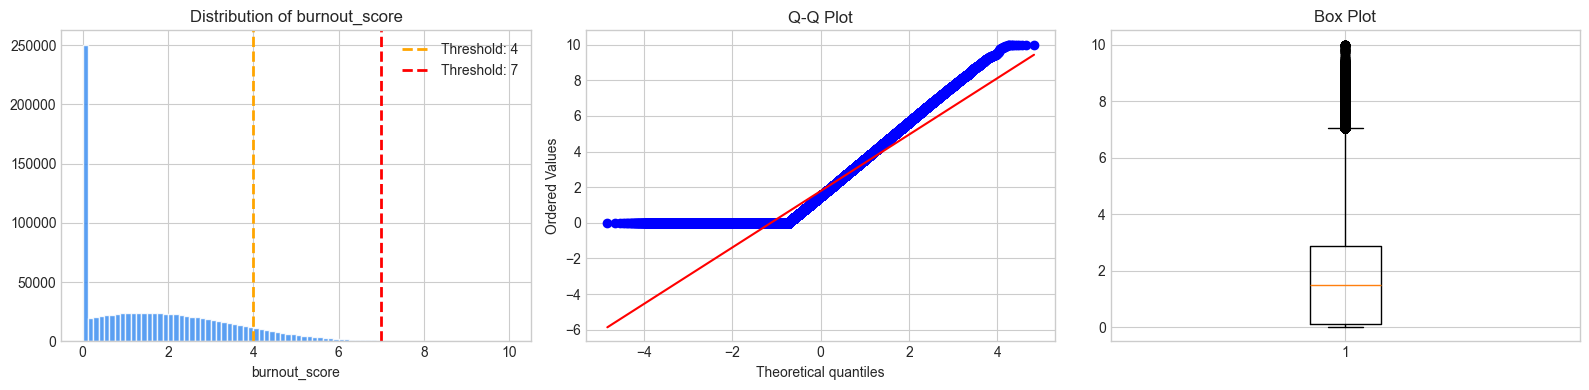


--- Class Distribution ---
  0 (Healthy        ):    886,497 ( 88.6%)
  1 (Mildly Burnout ):    109,563 ( 11.0%)
  2 (Burnout        ):      3,940 (  0.4%)


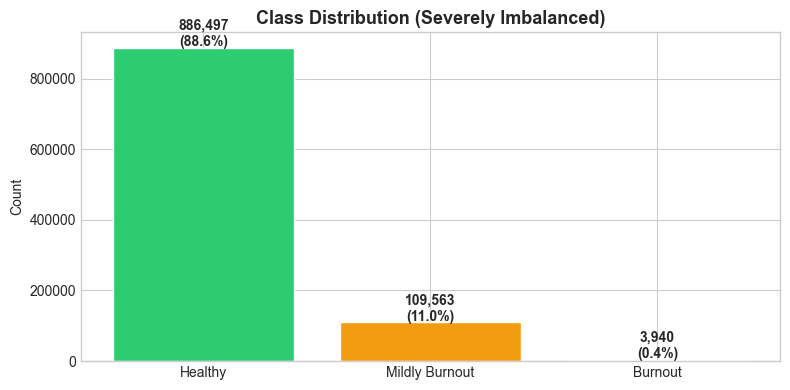


>>> IMBALANCED: Burnout class has only 3,940 samples (0.4%)
>>> A dummy classifier predicting all Healthy gets 88.6% accuracy
>>> Must use SMOTE + class_weight='balanced' + Macro F1 as primary metric


In [5]:
# Original distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["burnout_score"], bins=80, color="#3d8ef0", edgecolor="white", alpha=0.85)
axes[0].axvline(x=4, color="orange", linestyle="--", linewidth=2, label="Threshold: 4")
axes[0].axvline(x=7, color="red", linestyle="--", linewidth=2, label="Threshold: 7")
axes[0].set_title("Distribution of burnout_score")
axes[0].set_xlabel("burnout_score")
axes[0].legend()

stats.probplot(df["burnout_score"], plot=axes[1])
axes[1].set_title("Q-Q Plot")

axes[2].boxplot(df["burnout_score"], vert=True)
axes[2].set_title("Box Plot")

skew = df["burnout_score"].skew()
print(f"Skewness : {skew:.4f}")
print(f"Mean     : {df['burnout_score'].mean():.4f}")
print(f"Median   : {df['burnout_score'].median():.4f}")
print(f"Min/Max  : {df['burnout_score'].min():.4f} / {df['burnout_score'].max():.4f}")

plt.tight_layout()
plt.show()

# --- Bin into 3 classes ---
def bin_burnout(score):
    if score < 4:   return 0  # Healthy
    elif score < 7: return 1  # Mildly Burnout
    else:           return 2  # Burnout

df["burnout_class"] = df["burnout_score"].apply(bin_burnout)
df["risk_level_encoded"] = df["risk_level"].map({"Low": 0, "Medium": 1, "High": 2})
class_names = {0: "Healthy", 1: "Mildly Burnout", 2: "Burnout"}

print(f"\n--- Class Distribution ---")
for cls, name in class_names.items():
    cnt = (df["burnout_class"] == cls).sum()
    print(f"  {cls} ({name:15s}): {cnt:>10,} ({cnt/len(df)*100:5.1f}%)")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
counts = df["burnout_class"].value_counts().sort_index()
bars = ax.bar([class_names[i] for i in counts.index], counts.values,
              color=["#2ecc71", "#f39c12", "#e74c3c"], edgecolor="white")
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f"{cnt:,}\n({cnt/len(df)*100:.1f}%)", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Class Distribution (Severely Imbalanced)", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"\n>>> IMBALANCED: Burnout class has only {(df['burnout_class']==2).sum():,} samples (0.4%)")
print(f">>> A dummy classifier predicting all Healthy gets {(df['burnout_class']==0).sum()/len(df)*100:.1f}% accuracy")
print(f">>> Must use SMOTE + class_weight='balanced' + Macro F1 as primary metric")

## 2. IQR Impact — Clean Features Only, Preserve All Classes

Applying IQR to burnout_score would remove nearly all Burnout-class samples (score > 7). We must clean features only.

In [6]:
q1 = df["burnout_score"].quantile(0.25)
q3 = df["burnout_score"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr

print(f"Q1={q1:.3f}, Q3={q3:.3f}, IQR={iqr:.3f}")
print(f"IQR upper bound: {upper:.3f}")
print(f"\nRows with burnout_score > {upper:.1f}: {len(df[df['burnout_score'] > upper]):,}")
print(f"These overlap with Burnout class (>=7): {(df['burnout_class'] == 2).sum():,} samples")
print(f"\nIf IQR applied to target: almost ALL Burnout-class samples get removed!")
print(f">>> CONCLUSION: Apply IQR to FEATURE columns only, never the target.")

Q1=0.125, Q3=2.889, IQR=2.765
IQR upper bound: 7.036

Rows with burnout_score > 7.0: 3,735
These overlap with Burnout class (>=7): 3,940 samples

If IQR applied to target: almost ALL Burnout-class samples get removed!
>>> CONCLUSION: Apply IQR to FEATURE columns only, never the target.


## 3. Feature Correlation with `burnout_score`

In [7]:
corr = df.select_dtypes("number").corr()["burnout_score"].drop(["burnout_score", "burnout_class"]).sort_values(ascending=False)
print("Correlation with burnout_score:")
print("=" * 60)
for feat, val in corr.items():
    flag = ""
    if feat in ["mental_health_index", "risk_level_encoded", "dropout_risk"]:
        flag = " *** LEAKAGE - EXCLUDED"
    elif abs(val) < 0.05:
        flag = " (negligible - excluded)"
    elif abs(val) >= 0.2:
        flag = " << SELECTED"
    print(f"  {feat:25s} : {val:+.4f}{flag}")

Correlation with burnout_score:
  risk_level_encoded        : +0.8283 *** LEAKAGE - EXCLUDED
  stress_level              : +0.7531 << SELECTED
  dropout_risk              : +0.6897 *** LEAKAGE - EXCLUDED
  anxiety_score             : +0.6685 << SELECTED
  depression_score          : +0.6426 << SELECTED
  exam_pressure             : +0.4344 << SELECTED
  study_hours_per_day       : +0.3351 << SELECTED
  financial_stress          : +0.2957 << SELECTED
  family_expectation        : +0.2178 << SELECTED
  academic_performance      : +0.0571
  academic_year             : +0.0006 (negligible - excluded)
  age                       : -0.0010 (negligible - excluded)
  internet_usage            : -0.0012 (negligible - excluded)
  screen_time               : -0.0012 (negligible - excluded)
  physical_activity         : -0.1101
  social_support            : -0.2298 << SELECTED
  sleep_hours               : -0.3714 << SELECTED
  mental_health_index       : -0.7965 *** LEAKAGE - EXCLUDED


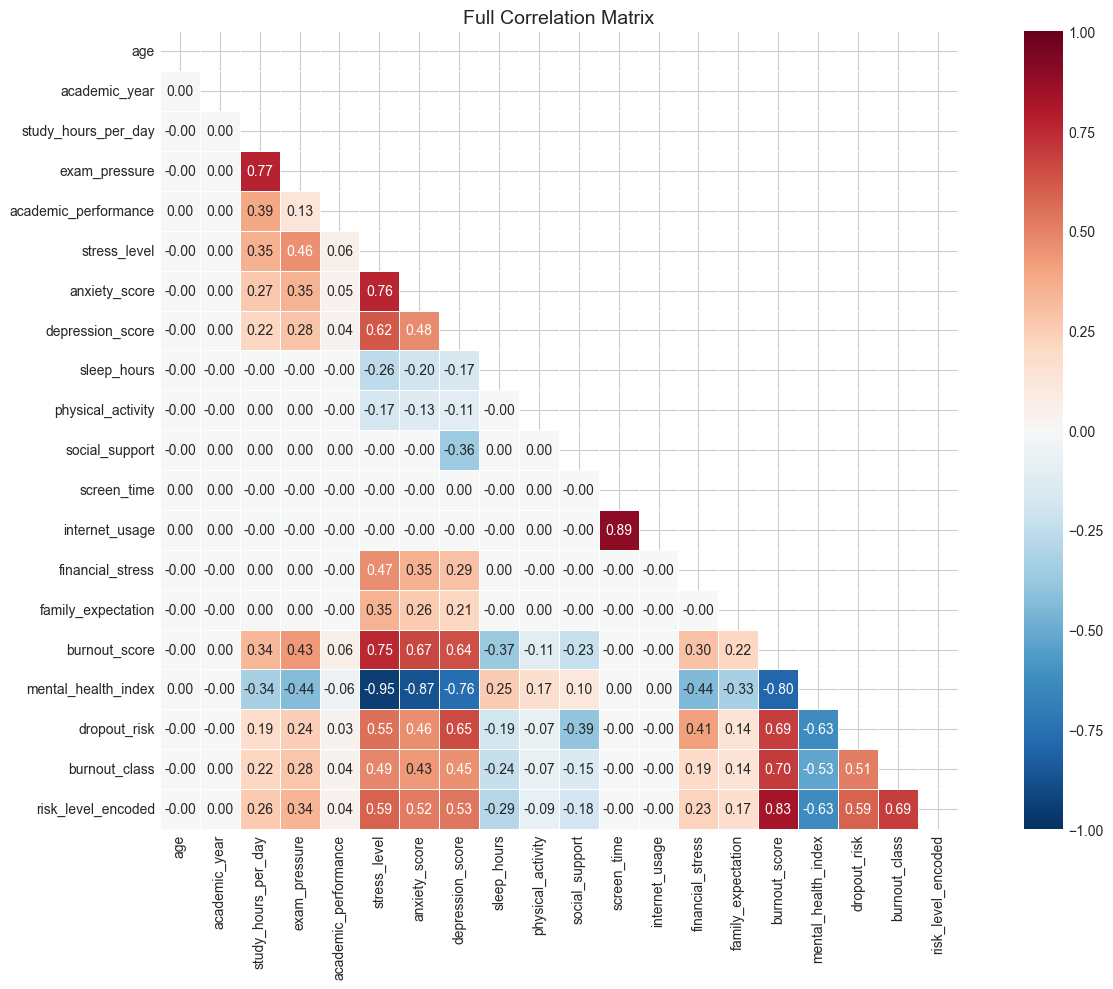

In [8]:
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df.select_dtypes("number").corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title("Full Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Leakage Column Analysis — Why They Are EXCLUDED

These 3 columns have suspiciously high correlation with `burnout_score` because they are likely **derived from** the target or closely related variables:
- `mental_health_index`: corr -0.80, and corr -0.95 with stress_level (almost certainly derived)
- `risk_level`: corr +0.83 (likely thresholded from burnout_score itself)
- `dropout_risk`: corr +0.69 (likely derived from burnout + other factors)

Using them would inflate metrics artificially. **EXCLUDED from model.**

In [9]:
print("Evidence of data leakage:")
print("=" * 55)
print(f"  mental_health_index vs stress_level:  {df['mental_health_index'].corr(df['stress_level']):+.4f}  (nearly -1 = derived)")
print(f"  mental_health_index vs burnout_score: {df['mental_health_index'].corr(df['burnout_score']):+.4f}")
# Inline the encoding so this cell works even if the prior cell hasn't run
_rl_num = df["risk_level"].map({"Low": 0, "Medium": 1, "High": 2})
print(f"  risk_level          vs burnout_score: {_rl_num.corr(df['burnout_score']):+.4f}  (suspiciously high)")
print(f"  dropout_risk        vs burnout_score: {df['dropout_risk'].corr(df['burnout_score']):+.4f}")
print(f"\n>>> All 3 columns EXCLUDED to avoid artificial metric inflation.")

Evidence of data leakage:
  mental_health_index vs stress_level:  -0.9494  (nearly -1 = derived)
  mental_health_index vs burnout_score: -0.7965
  risk_level          vs burnout_score: +0.8283  (suspiciously high)
  dropout_risk        vs burnout_score: +0.6897

>>> All 3 columns EXCLUDED to avoid artificial metric inflation.


## 5. Feature Selection — 10 Features (No Leakage)

**Selected (10):** study_hours_per_day, sleep_hours, exam_pressure, stress_level, financial_stress, social_support, anxiety_score, depression_score, family_expectation, physical_activity

**Excluded (leakage):** mental_health_index, risk_level, dropout_risk
**Excluded (negligible):** age, gender, academic_year, academic_performance, screen_time, internet_usage

## 6. Feature Distributions

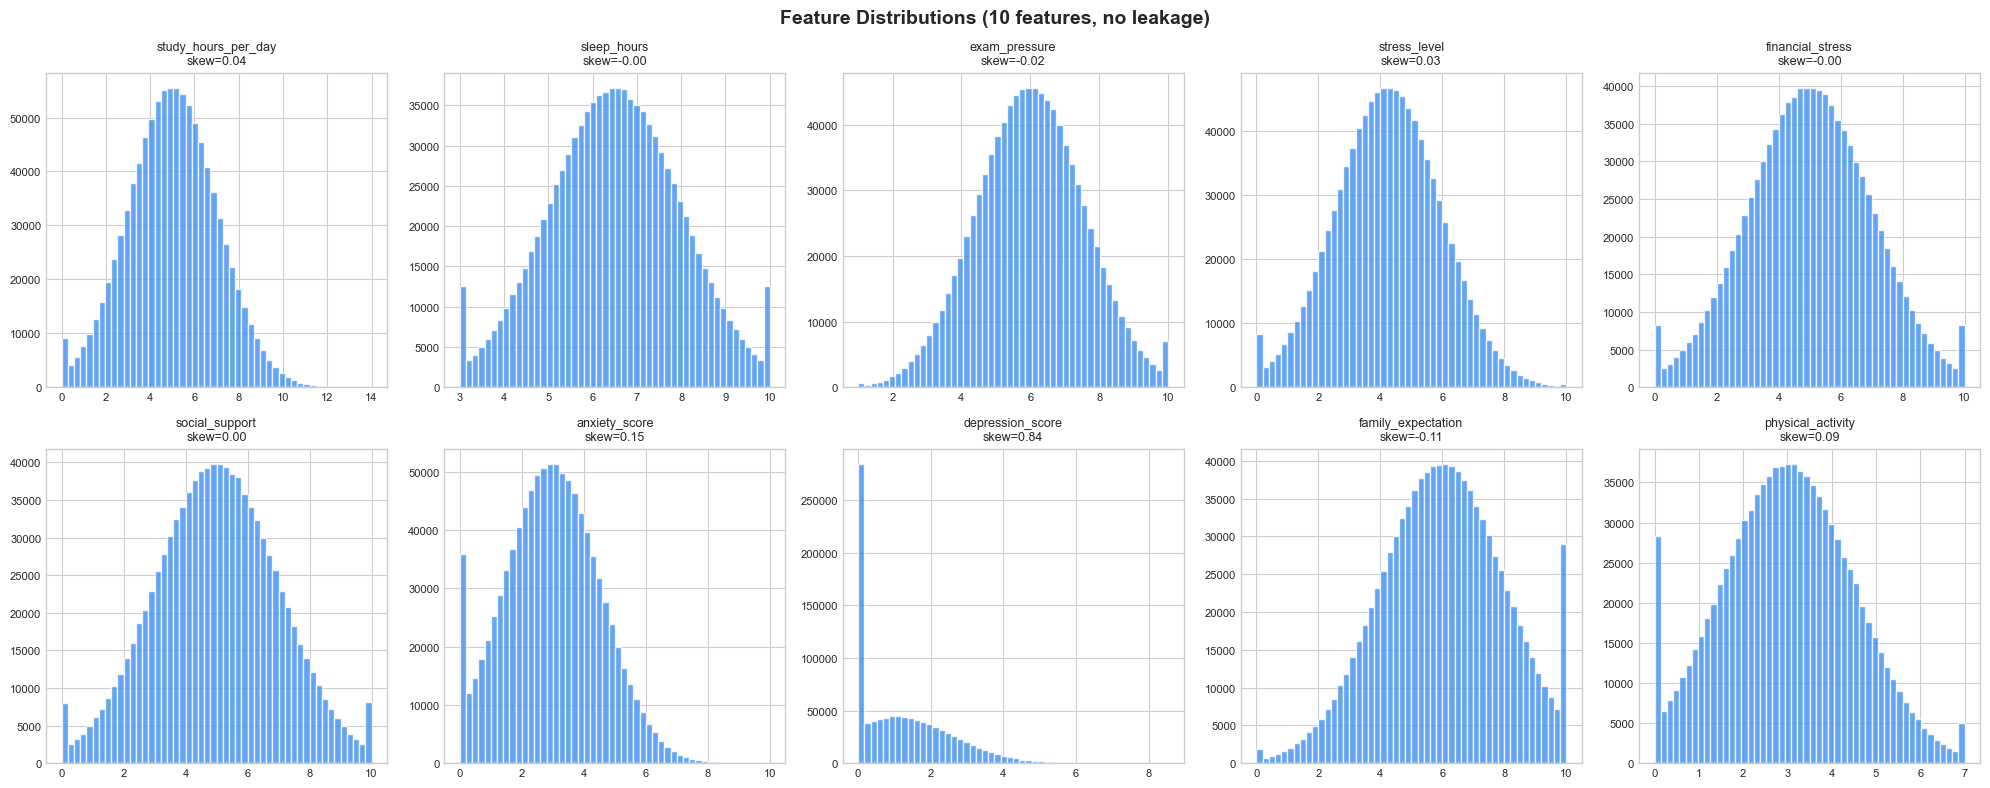

In [10]:
feature_cols = [
    "study_hours_per_day", "sleep_hours", "exam_pressure", "stress_level",
    "financial_stress", "social_support", "anxiety_score", "depression_score",
    "family_expectation", "physical_activity",
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(feature_cols):
    ax = axes[i // 5, i % 5]
    ax.hist(df[col], bins=50, color="#3d8ef0", edgecolor="white", alpha=0.8)
    ax.set_title(f"{col}\nskew={df[col].skew():.2f}", fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle("Feature Distributions (10 features, no leakage)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Per-Class Feature Distributions

How do features differ across burnout classes? Features that separate classes well will be most useful for classification.

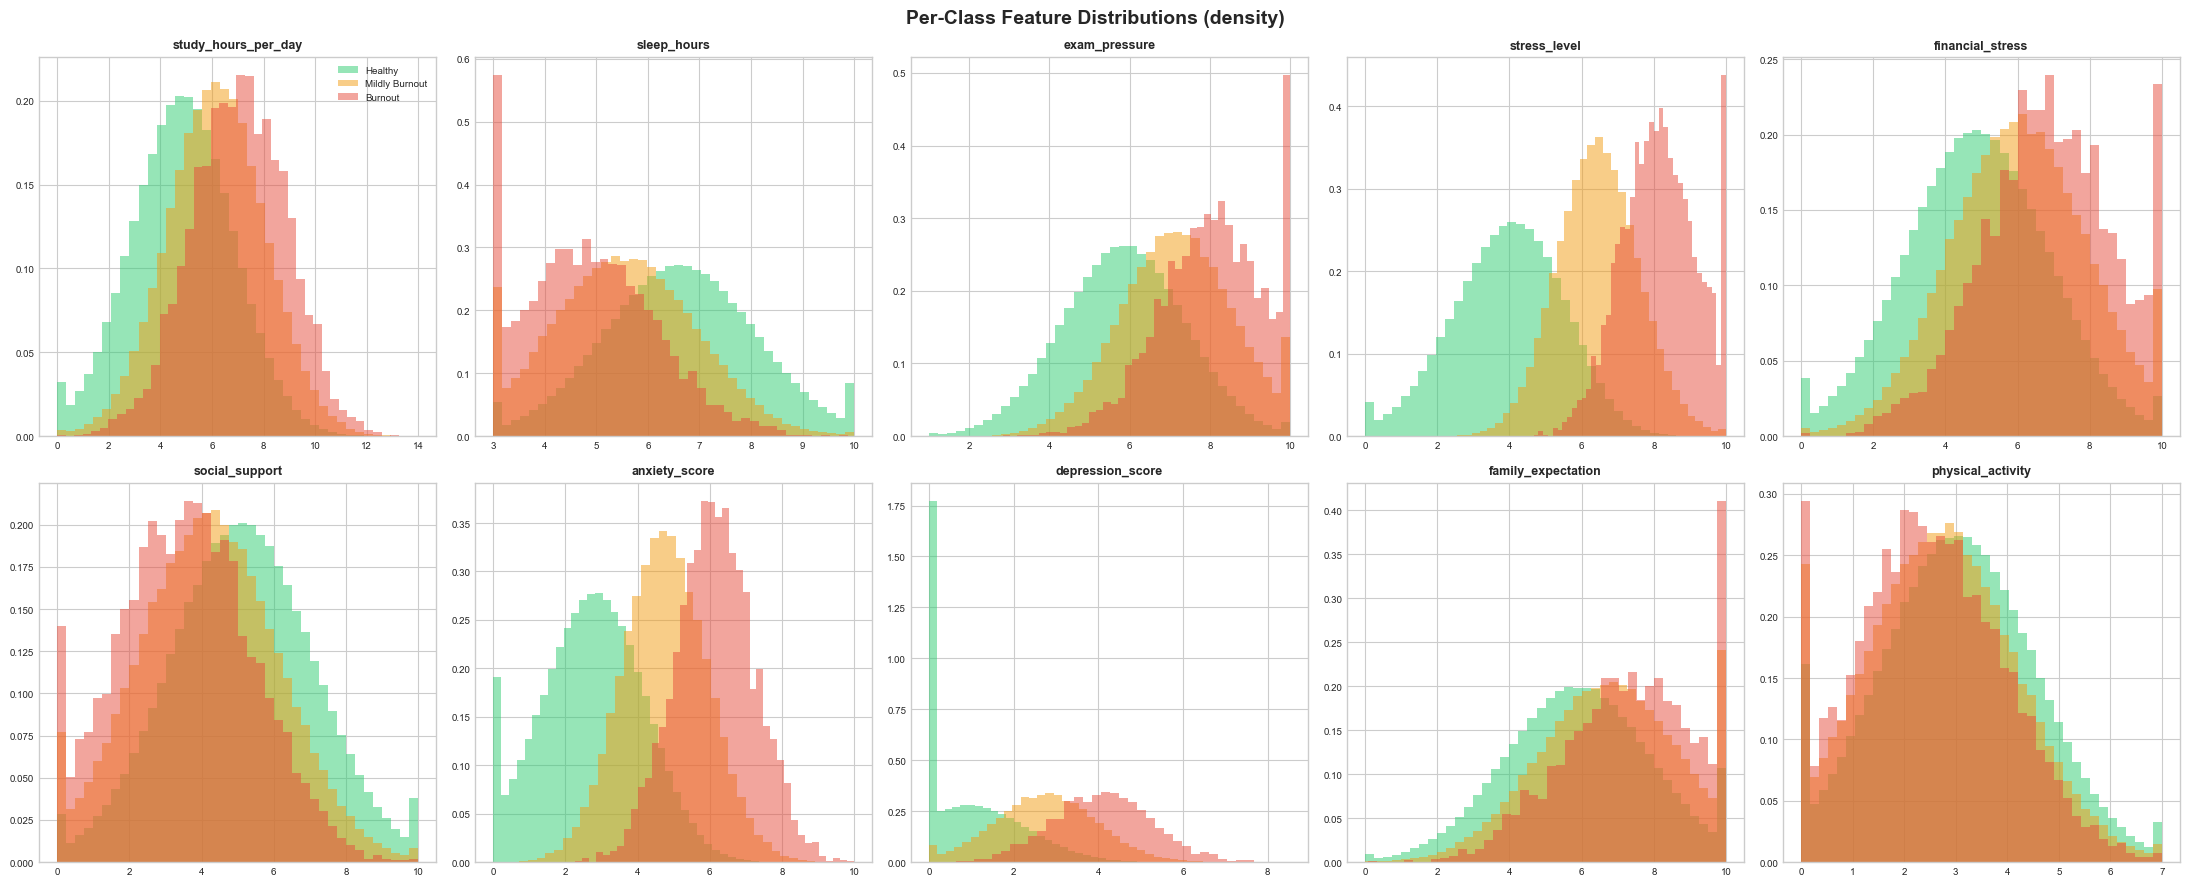

Mean feature values per class:
  study_hours_per_day      : Healthy=4.85  Mild=6.16  Burnout=7.04
  sleep_hours              : Healthy=6.63  Mild=5.56  Burnout=4.89
  exam_pressure            : Healthy=5.85  Mild=7.16  Burnout=8.03
  stress_level             : Healthy=3.96  Mild=6.45  Burnout=8.14
  financial_stress         : Healthy=4.87  Mild=6.02  Burnout=6.83
  social_support           : Healthy=5.10  Mild=4.20  Burnout=3.57
  anxiety_score            : Healthy=2.75  Mild=4.75  Burnout=6.14
  depression_score         : Healthy=1.08  Mild=2.76  Burnout=4.10
  family_expectation       : Healthy=5.89  Mild=6.72  Burnout=7.31
  physical_activity        : Healthy=3.05  Mild=2.73  Burnout=2.52


In [11]:
colors = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}
labels = {0: "Healthy", 1: "Mildly Burnout", 2: "Burnout"}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for i, col in enumerate(feature_cols):
    ax = axes[i // 5, i % 5]
    for cls in [0, 1, 2]:
        data = df[df["burnout_class"] == cls][col]
        ax.hist(data, bins=40, alpha=0.5, color=colors[cls], label=labels[cls], density=True)
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle("Per-Class Feature Distributions (density)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Per-class mean summary
print("Mean feature values per class:")
print("=" * 75)
for col in feature_cols:
    means = [df[df["burnout_class"] == c][col].mean() for c in [0, 1, 2]]
    print(f"  {col:25s}: Healthy={means[0]:.2f}  Mild={means[1]:.2f}  Burnout={means[2]:.2f}")

## 8. Multicollinearity Check (VIF)

In [12]:
from sklearn.preprocessing import StandardScaler

X_check = df[feature_cols].dropna()
X_scaled = StandardScaler().fit_transform(X_check)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

corr_features = X_scaled.corr().abs()
high_corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_features.iloc[i, j]
        if r > 0.7:
            high_corr_pairs.append((feature_cols[i], feature_cols[j], r))

if high_corr_pairs:
    print("High inter-feature correlations (|r| > 0.7):")
    for a, b, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f"  {a:25s} <-> {b:25s} : {r:.3f}")
    print("\n>>> Tree-based classifiers handle multicollinearity well.")
    print("    Interaction terms between these pairs may be redundant.")
else:
    print("No feature pairs with |r| > 0.7. Low multicollinearity.")

High inter-feature correlations (|r| > 0.7):
  study_hours_per_day       <-> exam_pressure             : 0.766
  stress_level              <-> anxiety_score             : 0.761

>>> Tree-based classifiers handle multicollinearity well.
    Interaction terms between these pairs may be redundant.


## 9. Summary & Recommendations for Model A

1. **Classification approach**: Bin burnout_score into 3 classes (Healthy/Mild/Burnout) with thresholds 4/7
2. **Severely imbalanced**: Healthy 88.6%, Mild 11%, Burnout 0.4% → use SMOTE + class_weight='balanced'
3. **Primary metric**: Macro F1 (not accuracy — a dummy classifier gets 88.6% accuracy)
4. **10 features** selected (NO leakage columns)
5. **IQR on features only** — preserve all Burnout-class samples
6. **Feature engineering**: Interactions (stress x anxiety, stress x depression), squared terms, threshold flags
7. **Algorithms**: LightGBM, XGBoost, CatBoost, RF classifiers with Optuna tuning
8. **App gauge**: Use `predict_proba` weighted pseudo-score to preserve gauge visualization